# Përgatitja dhe Pastrimi i të Dhënave

**Dataset:** Airbnb New York City 2019  
**Qëllimi:** Të përgatitet dataseti për analizë duke kontrolluar strukturën, vlerat e munguara, duplikatat, outliers dhe tipet e të dhënave.

Ky notebook fokusohet vetëm në fazën e preprocessing. Analizat dhe vizualizimet kryesore gjenden në notebook-ët e analizës.


## Përmbajtja

1. Importimi i librarive dhe datasetit  
2. Kontrolli fillestar i të dhënave  
3. Vlerat e munguara  
4. Duplikatat  
5. Outliers në çmim  
6. Konvertimi i tipeve dhe pastrimi final  
7. Përmbledhja para/pas dhe eksportimi


---
## 1. Importimi i librarive


In [21]:
# Importimi i librarive të nevojshme për analizë
import pandas as pd       # Për manipulim të të dhënave
import numpy as np        # Për operacione numerike
import matplotlib.pyplot as plt   # Për vizualizime
import seaborn as sns     # Për grafika statistikore

# Konfigurimi i stilit të grafikëve
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)



## 2. Ngarkimi i datasetit

Fillimisht lexohet dataseti origjinal dhe krijohet një kopje pune. Kjo është praktikë e mirë sepse dataseti origjinal mbetet i pandryshuar.


In [22]:
# Ngarkimi i datasetit nga skedari CSV
df = pd.read_csv("AB_NYC_2019.csv")

# Krijimi i një kopje pune për të ruajtur të dhënat origjinale të pandryshuara
K = df.copy()

print(f"✅ Dataseti u ngarkua me sukses.")
print(f"   Numri i rreshtave : {K.shape[0]:,}")
print(f"   Numri i kolonave  : {K.shape[1]}")

✅ Dataseti u ngarkua me sukses.
   Numri i rreshtave : 48,895
   Numri i kolonave  : 16


---
## 3. Kontrolli fillestar i të dhënave

Në këtë pjesë kontrollojmë pamjen e parë të datasetit, kolonat kryesore, tipet e të dhënave dhe statistikat bazë.


### 3.1 Shikimi i rreshtave të parë


In [23]:
K.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### 3.2 Zgjedhja e disa kolonave kryesore

Kjo tabelë e vogël ndihmon për ta parë më lehtë strukturën e datasetit.


In [24]:
K_small = K[[
    "id",
    "neighbourhood_group",
    "room_type",
    "price",
    "minimum_nights",
    "availability_365"
]]

K_small.head()

,id,neighbourhood_group,room_type,price,minimum_nights,availability_365
0,2539,Brooklyn,Private room,149,1,365
1,2595,Manhattan,Entire home/apt,225,1,355
2,3647,Manhattan,Private room,150,3,365
3,3831,Brooklyn,Entire home/apt,89,1,194
4,5022,Manhattan,Entire home/apt,80,10,0


### 3.3 Informacioni strukturor

`info()` tregon tipet e kolonave dhe sa vlera jo-null ka secila kolonë.


In [25]:
K.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

### 3.4 Statistikat përshkruese

`describe()` jep përmbledhje numerike për kolonat kryesore.


In [26]:
K.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


---
## 4. Analiza dhe trajtimi i vlerave të munguara

Vlerat e munguara mund të ndikojnë në cilësinë e analizës. Prandaj fillimisht identifikohen, pastaj trajtohen sipas rëndësisë së kolonës.


In [27]:
missing_count = K.isnull().sum()
missing_pct   = (missing_count / len(K) * 100).round(2)

missing_df = pd.DataFrame({
    "Kolona"       : missing_count.index,
    "Mungesa (nr)" : missing_count.values,
    "Mungesa (%)"  : missing_pct.values
}).query("`Mungesa (nr)` > 0").reset_index(drop=True)

print("📋 Kolonat me vlera të munguara:\n")
print(missing_df.to_string(index=False))

📋 Kolonat me vlera të munguara:

           Kolona  Mungesa (nr)  Mungesa (%)
             name            16         0.03
        host_name            21         0.04
      last_review         10052        20.56
reviews_per_month         10052        20.56


### 4.1 Strategjia për vlerat e munguara

| Kolona | Strategjia | Arsyeja |
|---|---|---|
| `name` | Hiq rreshtat bosh | Janë shumë pak raste dhe nuk ndikojnë shumë në dataset |
| `host_name` | Hiq rreshtat bosh | Janë shumë pak raste |
| `reviews_per_month` | Zëvendëso me medianë ose 0 sipas qasjes në kod | Vlera mungon zakonisht kur listimi nuk ka reviews |
| `last_review` | Konverto në datë dhe krijo variabël ndihmëse | Nevojitet për analizë të aktivitetit |


In [28]:
# Trajtimi i vlerave të munguara

# name dhe host_name — drop rreshtat (0.03% dhe 0.04% e datasetit)
K = K.dropna(subset=["name", "host_name"])

# reviews_per_month — zëvendëso me medianë
# Arsyeja: mediana është rezistente ndaj outlier-ave dhe shpërndarjes right-skewed
median_rpm = K["reviews_per_month"].median()
K["reviews_per_month"] = K["reviews_per_month"].fillna(median_rpm)

# last_review — mbetet NaN (tregon listingje pa asnjë review)

# Verifikimi
print("✅ Vlerat e munguara pas trajtimit:\n")
print(K.isnull().sum()[K.isnull().sum() > 0])
print(f"\n➡️  Vetëm 'last_review' ka NaN — e qëllimshme.")
print(f"📋 Rreshtat pas trajtimit: {len(K):,}")

✅ Vlerat e munguara pas trajtimit:

last_review    10037
dtype: int64

➡️  Vetëm 'last_review' ka NaN — e qëllimshme.
📋 Rreshtat pas trajtimit: 48,858


### 4.2 Transformimi i `last_review`

Kolona `last_review` konvertohet në format date. Pastaj krijohet një kolonë e re që tregon sa ditë kanë kaluar nga review i fundit.


In [29]:
# Konvertimi i last_review nga string → datetime (duhet bërë para transformimit)
K["last_review"] = pd.to_datetime(K["last_review"], errors="coerce")

# Tani transformimi funksionon
reference_date = pd.Timestamp("2019-12-31")
K["days_since_last_review"] = (reference_date - K["last_review"]).dt.days
K["days_since_last_review"] = K["days_since_last_review"].fillna(K["days_since_last_review"].max())

# Heqja e kolonës origjinale
K = K.drop(columns=["last_review"])

print("✅ Kolona 'days_since_last_review' u krijua me sukses.")
print(f"   Min  : {K['days_since_last_review'].min():.0f} ditë")
print(f"   Max  : {K['days_since_last_review'].max():.0f} ditë")
print(f"   Media: {K['days_since_last_review'].median():.0f} ditë")
print(f"\n✅ Vlera të munguara të mbetura: {K.isnull().sum().sum()}")

✅ Kolona 'days_since_last_review' u krijua me sukses.
   Min  : 176 ditë
   Max  : 3200 ditë
   Media: 362 ditë

✅ Vlera të munguara të mbetura: 0


**Shënim:** Për listimet pa review, mungesa në `last_review` nuk do të thotë domosdoshmërisht gabim. Shpesh tregon se listimi nuk ka marrë ende vlerësime. Për këtë arsye krijimi i një kolone si `days_since_last_review` e bën më të lehtë analizën e aktivitetit.


---
## 5. Trajtimi i duplikatave

Duplikatat mund t'i japin peshë të dyfishtë të njëjtit listim dhe të shtrembërojnë rezultatet.


In [30]:
# Identifikimi i duplikatave
num_duplicates = K.duplicated().sum()
print(f"📋 Numri i rreshtave të duplikuar: {num_duplicates}")

if num_duplicates > 0:
    K = K.drop_duplicates().reset_index(drop=True)
    print(f"✅ Duplikatat u hoqën. Rreshtat mbetur: {len(K):,}")
else:
    print("✅ Nuk ka duplikate — dataseti është i pastër në këtë aspekt.")

📋 Numri i rreshtave të duplikuar: 0
✅ Nuk ka duplikate — dataseti është i pastër në këtë aspekt.


---
## 6. Identifikimi dhe trajtimi i outliers në çmim

Outliers janë vlera shumë të larta ose shumë të ulëta krahasuar me shumicën e të dhënave. Në këtë dataset, outliers në `price` janë të rëndësishëm sepse mund ta rrisin artificialisht mesataren.


In [31]:
# Statistikat e çmimit para trajtimit
print("📊 Statistikat e kolonës 'price' para trajtimit:")
print(K["price"].describe())
print(f"\n⚠️  Listingje me çmim = 0  : {(K['price'] == 0).sum()}")
print(f"⚠️  Listingje me çmim > 1000: {(K['price'] > 1000).sum()}")

📊 Statistikat e kolonës 'price' para trajtimit:
count    48858.000000
mean       152.740309
std        240.232386
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

⚠️  Listingje me çmim = 0  : 11
⚠️  Listingje me çmim > 1000: 239


### 6.1 Boxplot i çmimeve

Boxplot ndihmon për t'i parë vizualisht vlerat ekstreme.


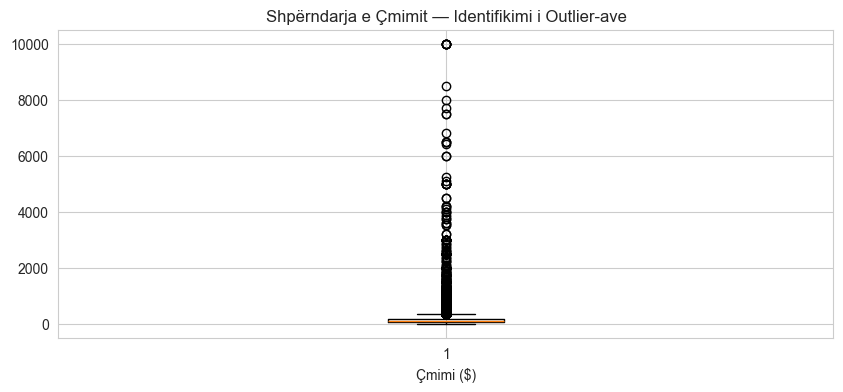

In [32]:
# Boxplot i thjeshtë për të parë outlier-at e çmimit
plt.figure(figsize=(10, 4))
plt.boxplot(K["price"])
plt.title("Shpërndarja e Çmimit — Identifikimi i Outlier-ave")
plt.xlabel("Çmimi ($)")
plt.show()

### 6.2 Identifikimi me metodën IQR

Metoda IQR përdor kuartilin e parë dhe të tretë për të përcaktuar kufijtë normalë të çmimeve.


In [33]:
# Identifikimi i outlier-ave me metodën IQR
Q1  = K["price"].quantile(0.25)
Q3  = K["price"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = max(0, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

outliers = K[(K["price"] < lower_bound) | (K["price"] > upper_bound)]

print(f"Q1 = {Q1}  |  Q3 = {Q3}  |  IQR = {IQR}")
print(f"Kufiri i poshtëm = {lower_bound}  |  Kufiri i sipërm = {upper_bound:.2f}")
print(f"Numri i outlier-ave: {len(outliers):,} rreshta")
print(f"Përqindja e outlier-ave: {len(outliers)/len(K)*100:.2f}%")

Q1 = 69.0  |  Q3 = 175.0  |  IQR = 106.0
Kufiri i poshtëm = 0  |  Kufiri i sipërm = 334.00
Numri i outlier-ave: 2,971 rreshta
Përqindja e outlier-ave: 6.08%


### 6.3 Kontrolli i reviews për outliers

Kjo pjesë ndihmon të kuptohet nëse outliers janë listime aktive apo listime me pak/aspak aktivitet.


In [34]:
# Shikojmë nëse outlier-at kanë reviews
print("📊 Statistikat e reviews për outlier-at:\n")
print(f"Outlier-at me 0 reviews      : {(outliers['number_of_reviews'] == 0).sum()}")
print(f"Outlier-at me reviews > 0    : {(outliers['number_of_reviews'] > 0).sum()}")
print(f"Mesatarja e reviews          : {outliers['number_of_reviews'].mean():.1f}")
print(f"\nKrahasim me dataset-in normal:")
normal = K[(K["price"] >= lower_bound) & (K["price"] <= upper_bound)]
print(f"Mesatarja e reviews (normal) : {normal['number_of_reviews'].mean():.1f}")
print(f"Mesatarja e reviews (outlier): {outliers['number_of_reviews'].mean():.1f}")

📊 Statistikat e reviews për outlier-at:

Outlier-at me 0 reviews      : 1039
Outlier-at me reviews > 0    : 1932
Mesatarja e reviews          : 13.0

Krahasim me dataset-in normal:
Mesatarja e reviews (normal) : 23.9
Mesatarja e reviews (outlier): 13.0


### 6.4 Heqja e outliers

Pas analizës, outliers largohen nga dataseti i punës që analiza kryesore të mos ndikohet nga vlera shumë ekstreme.


In [35]:
# Heqja e outlier-ave bazuar në metodën IQR
# Justifikim: 35% e outlier-ave kanë zero reviews dhe mesatarja e reviews
# është dyfish më e ulët (13.0 vs 23.9) — tregues i listingjeve joaktive

K = K[(K["price"] >= lower_bound) & (K["price"] <= upper_bound)].copy()
K = K.reset_index(drop=True)

print(f"✅ Outlier-at u hoqën me sukses.")
print(f"   Rreshtat para heqjes : 48,895")
print(f"   Rreshtat pas heqjes  : {len(K):,}")
print(f"   Rreshtat e hequr     : 2,971 ({2971/48895*100:.2f}%)")

✅ Outlier-at u hoqën me sukses.
   Rreshtat para heqjes : 48,895
   Rreshtat pas heqjes  : 45,887
   Rreshtat e hequr     : 2,971 (6.08%)


### 6.5 Përmbledhje e gjetjeve për outliers

- Disa çmime janë shumë më të larta se shumica e listimeve.
- Një pjesë e outliers mund të jenë prona luksoze ose lokacione shumë të kërkuara.
- Disa mund të jenë gabime në të dhëna ose listime jo tipike.
- Për analizë më të drejtë, është e arsyeshme të raportohet dhe të trajtohet ndikimi i tyre.


In [36]:
K_clean = K.copy()
print(f"✅ K u përditësua — {len(K):,} rreshta aktive.")

✅ K u përditësua — 45,887 rreshta aktive.


---
## 7. Konvertimi i tipeve dhe pastrimi final

Në këtë pjesë kolonat kategorike konvertohen në tipin `category` dhe hiqen listimet me çmim të pavlefshëm.


In [37]:
# Konvertimi i kolonave kategorike
K["neighbourhood_group"] = K["neighbourhood_group"].astype("category")
K["neighbourhood"]       = K["neighbourhood"].astype("category")
K["room_type"]           = K["room_type"].astype("category")

# Verifikimi
print("✅ Tipi i të dhënave pas konvertimit:\n")
print(K[["neighbourhood_group", "neighbourhood", "room_type"]].dtypes)

✅ Tipi i të dhënave pas konvertimit:

neighbourhood_group    category
neighbourhood          category
room_type              category
dtype: object


### 7.1 Heqja e çmimeve zero

Çmimi `0` nuk është realist për një rezervim Airbnb, prandaj këto rreshta largohen.


In [38]:
# Heqja e listingjeve me çmim = 0 (të dhëna të pavlefshme)
K = K[K["price"] > 0].copy()
K = K.reset_index(drop=True)

print(f"✅ Listingjet me çmim 0$ u hoqën.")
print(f"   Rreshtat pas heqjes: {len(K):,}")

✅ Listingjet me çmim 0$ u hoqën.
   Rreshtat pas heqjes: 45,876


---
## 8. Përmbledhja para dhe pas pastrimit

Kjo tabelë tregon ndryshimin mes datasetit origjinal dhe datasetit të pastruar.


In [39]:
# Tabela krahasuese: dataseti origjinal vs. i pastruar
summary = pd.DataFrame({
    "Metrika"               : ["Rreshtat", "Kolonat", "Vlera të munguara (total)", 
                               "Duplikate", "Çmime = 0", "Outlier-at e çmimit"],
    "Origjinali (df)"       : [
        df.shape[0], df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        (df["price"] == 0).sum(),
        ((df["price"] > upper_bound)).sum()
    ],
    "Pas Pastrimit (K)"     : [
        K.shape[0], K.shape[1],
        K.isnull().sum().sum(),
        K.duplicated().sum(),
        (K["price"] == 0).sum(),
        "—"
    ]
})

print("📋 TABELA KRAHASUESE — PARA DHE PAS PASTRIMIT\n")
print(summary.to_string(index=False))
print(f"\n✅ Pastrimi i të dhënave u përfundua me sukses!")
print(f"   Dataseti final: {len(K):,} rreshta × {K.shape[1]} kolona")

📋 TABELA KRAHASUESE — PARA DHE PAS PASTRIMIT

                  Metrika  Origjinali (df) Pas Pastrimit (K)
                 Rreshtat            48895             45876
                  Kolonat               16                16
Vlera të munguara (total)            20141                 0
                Duplikate                0                 0
                Çmime = 0               11                 0
      Outlier-at e çmimit             2972                 —

✅ Pastrimi i të dhënave u përfundua me sukses!
   Dataseti final: 45,876 rreshta × 16 kolona


---
## 9. Eksportimi i datasetit të pastruar

Dataseti final ruhet si CSV që të përdoret në notebook-ët e analizës dhe vizualizimit.


In [40]:
K.to_csv("cleaned_airbnb.csv", index=False)

## Përfundim

Pas këtyre hapave, dataseti është më i pastër dhe më i përshtatshëm për analizë:

- janë kontrolluar vlerat e munguara;
- janë trajtuar duplikatat;
- janë analizuar dhe trajtuar outliers në çmim;
- janë konvertuar tipet e rëndësishme të kolonave;
- është ruajtur një version i pastruar i datasetit.
